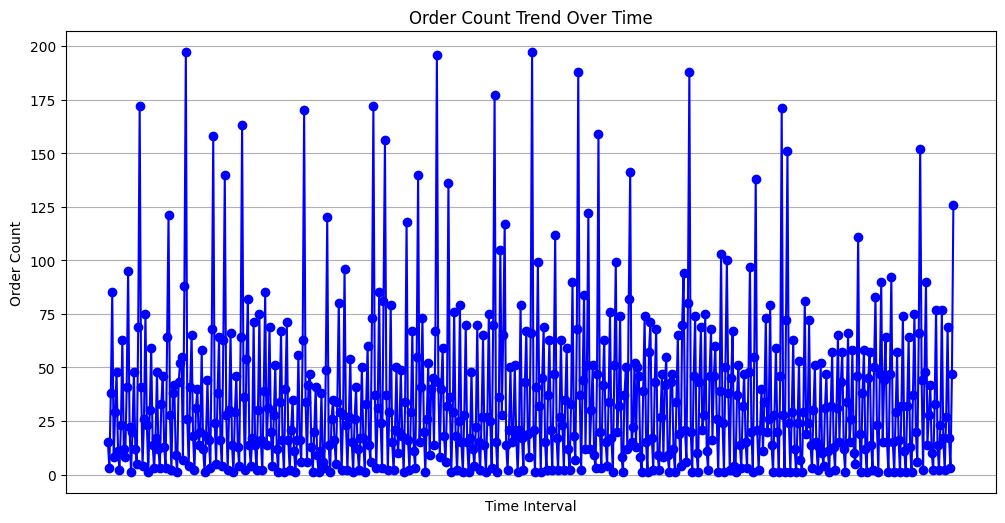

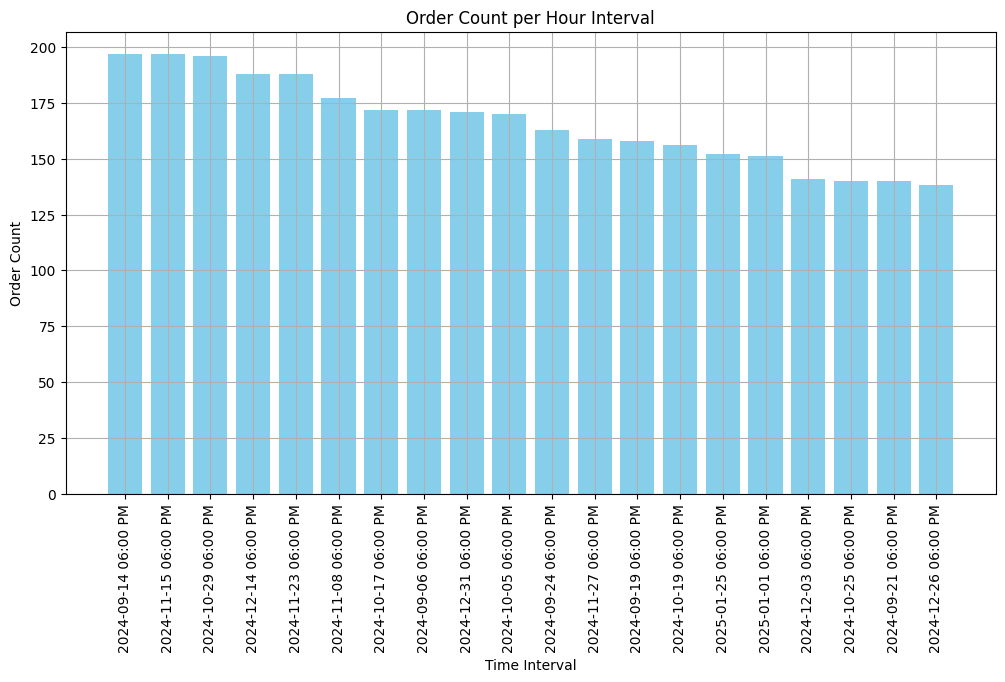

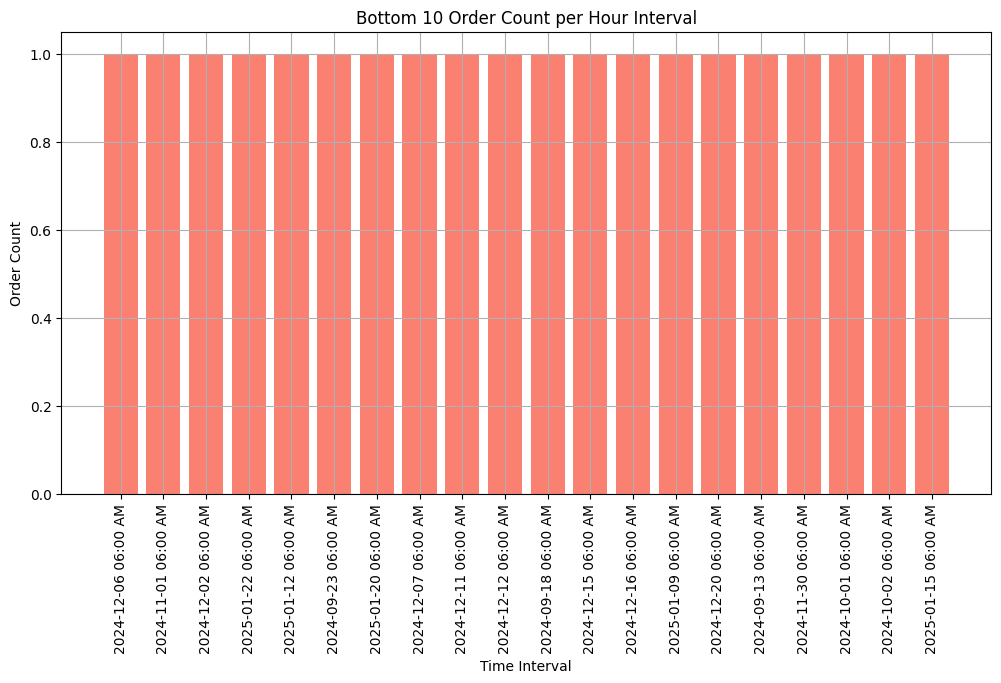


Bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):
   Order Hour Range  Order Count
2024-12-06 06:00 AM            1
2024-11-01 06:00 AM            1
2024-12-02 06:00 AM            1
2025-01-22 06:00 AM            1
2025-01-12 06:00 AM            1
2024-09-23 06:00 AM            1
2025-01-20 06:00 AM            1
2024-12-07 06:00 AM            1
2024-12-11 06:00 AM            1
2024-12-12 06:00 AM            1
2024-09-18 06:00 AM            1
2024-12-15 06:00 AM            1
2024-12-16 06:00 AM            1
2025-01-09 06:00 AM            1
2024-12-20 06:00 AM            1
2024-09-13 06:00 AM            1
2024-11-30 06:00 AM            1
2024-10-01 06:00 AM            1
2024-10-02 06:00 AM            1
2025-01-15 06:00 AM            1
2024-10-16 06:00 AM            1
2024-10-14 06:00 AM            1
2024-11-07 06:00 AM            1
2025-01-18 06:00 AM            1
2024-11-09 06:00 AM            1
2024-11-03 06:00 AM            1
2025-01-23 06:00 AM            1

,Order Hour Range,Order Count
0,2024-09-01 12:00 AM,15
1,2024-09-01 06:00 AM,3
2,2024-09-01 12:00 PM,38
3,2024-09-01 06:00 PM,85
4,2024-09-02 12:00 AM,8
...,...,...
95,2024-09-25 06:00 AM,2
96,2024-09-25 12:00 PM,54
97,2024-09-25 06:00 PM,82
98,2024-09-26 12:00 AM,14


In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tệp CSV và thêm cột đếm số lượng đơn hàng theo khung giờ
def process_data(file_path):
    df = pd.read_csv(file_path)
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    
    # Tạo cột 'Order Hour Range' để nhóm theo từng khung giờ (cách nhau 6 tiếng)
    df['Order Hour Range'] = df['Order Placed At'].dt.floor('6h')#.dt.strftime('%Y-%m-%d %I:00 %p')
    
    # Đếm số lượng đơn hàng theo từng khung giờ
    order_counts = df.groupby('Order Hour Range').size().reset_index(name='Order Count')
    order_counts['Order Hour Range'] = pd.to_datetime(order_counts['Order Hour Range'], format='%Y-%m-%d %I:%M %p')
    order_counts = order_counts.sort_values(by='Order Hour Range')
    order_counts['Order Hour Range'] = order_counts['Order Hour Range'].dt.strftime('%Y-%m-%d %I:00 %p')
    
    

    # Vẽ biểu đồ đường thể hiện số đơn hàng theo từng khung giờ theo thời gian
    plt.figure(figsize=(12, 6))
    plt.plot(order_counts['Order Hour Range'], order_counts['Order Count'], marker='o', linestyle='-', color='b')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count Trend Over Time')
    plt.xticks([])
    plt.grid()
    plt.show()

    # # Vẽ biểu đồ tròn phân phối số lượng đơn hàng
    # plt.figure(figsize=(8, 8))
    # bins = [0, 25, 50, 75, float('inf')]
    # labels = ['Dưới 25', '25-50', '50-75', 'Trên 75']
    # order_counts['Order Category'] = pd.cut(order_counts['Order Count'], bins=bins, labels=labels, right=False)
    # category_counts = order_counts['Order Category'].value_counts()
    
    # plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'gold', 'lightblue', 'lightgreen'])
    # plt.title('Phân phối số lượng đơn hàng theo nhóm')
    # plt.show()

    # Vẽ biểu đồ số lượng đơn hàng theo thời gian
    plt.figure(figsize=(12, 6))
    top_20_orders = order_counts.sort_values(by='Order Count', ascending=False).head(20)
    plt.bar(top_20_orders['Order Hour Range'], top_20_orders['Order Count'], color='skyblue')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng ít nhất theo thời gian
    plt.figure(figsize=(12, 6))
    bottom_20_orders = order_counts.sort_values(by='Order Count', ascending=True).head(20)
    plt.bar(bottom_20_orders['Order Hour Range'], bottom_20_orders['Order Count'], color='salmon')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Bottom 10 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

 # Xuất bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (hiển thị 100 dòng đầu tiên)
    sorted_order_counts = order_counts.sort_values(by='Order Count', ascending=True).head(100)
    print("\nBảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):")
    print(sorted_order_counts.to_string(index=False))
    return order_counts

# Đường dẫn đến tệp dữ liệu đầu vào
file_path = "cleaned_order_history.csv"
processed_df = process_data(file_path)

processed_df.head(100)


Tạo 2 cột Order Hour Range (cách nhau 6 tiếng) và Order Count (số lượng đơn hàng) để rút ra insight trong quá khứ thông qua các biểu đồ:
- Khung giờ có nhiều đơn hàng nhất là từ 6:00 PM tới 12:00 AM hôm sau.
- Khung giờ có ít đơn hàng nhất là từ 6:00 AM tới 12:00 PM:
  + 6AM - 8AM: Các khu vực như Gurugram, Noida, và Ghaziabad thường chứng kiến ùn tắc nhẹ đến trung bình ở các điểm nút.
  + 8AM - 10AM: Đây là giờ cao điểm chính, Khu vực trung tâm Delhi có thể bị tắc nghẽn do lượng xe lớn, Các khu công nghiệp ở Noida và Faridabad cũng làm tăng áp lực giao thông trên các tuyến đường.
  + 10AM - 12PM: Giao thông bắt đầu giảm dần sau giờ cao điểm, nhưng vẫn có thể đông ở những khu vực thương mại và văn phòng như Nehru Place, Saket, và Cyber City (Gurugram).


Một số điểm nóng giao thông thường gặp:
- Delhi-Gurugram Border (NH-48): Thường xuyên ùn tắc vào buổi sáng do lượng xe từ Gurugram vào Delhi.
- DND Flyway: Kết nối Noida với Delhi, dễ bị chậm trễ nếu có kiểm tra xe hoặc lưu lượng cao.
- Ghaziabad (NH-24/NH-9): Giao thông đông đúc do kết nối với phía đông Delhi.
- Ring Road: Các đoạn gần ISBT Kashmiri Gate, Sarai Kale Khan thường xuyên tắc nghẽn.


Columns in processed_df: Index(['Order Hour Range', 'Order Count'], dtype='object')


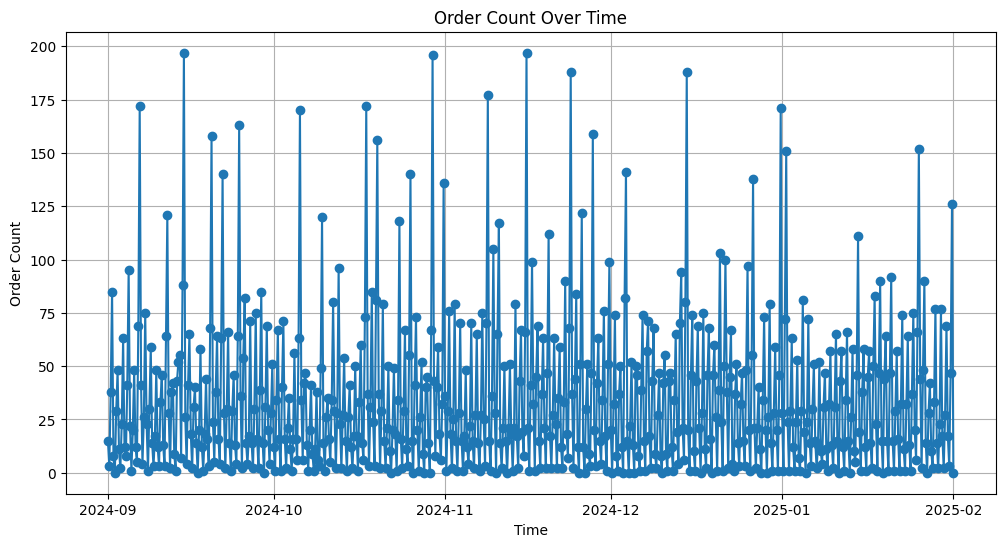

<Figure size 1200x600 with 0 Axes>

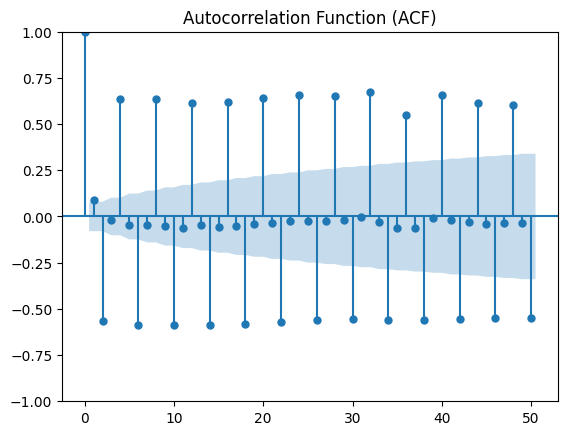

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

# 📌 Kiểm tra danh sách cột trước khi đặt chỉ mục
print("Columns in processed_df:", processed_df.columns)

# 📌 Đặt chỉ mục nếu cột 'Order Hour Range' vẫn còn trong DataFrame
if "Order Hour Range" in processed_df.columns:
    processed_df.set_index("Order Hour Range", inplace=True)

# 📌 Kiểm tra kiểu dữ liệu của chỉ mục
if not isinstance(processed_df.index, pd.DatetimeIndex):
    processed_df.index = pd.to_datetime(processed_df.index, errors="coerce")

# 📌 1️⃣ Vẽ biểu đồ chuỗi thời gian
plt.figure(figsize=(12, 6))
plt.plot(processed_df.index, processed_df["Order Count"], marker='o', linestyle='-')
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Order Count Over Time")
plt.grid()
plt.show()

# 📌 2️⃣ Kiểm tra tự tương quan ACF
plt.figure(figsize=(12, 6))
plot_acf(processed_df["Order Count"], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# # 📌 3️⃣ Phân rã chuỗi thời gian bằng STL
# period = 4  # Thay đổi tùy theo dữ liệu
# stl = STL(processed_df["Order Count"], period=period)
# result = stl.fit()

# plt.figure(figsize=(12, 8))
# result.plot()
# plt.show()


KIỂM TRA ĐỘ DỪNG CỦA ORDER COUNT BẰNG BIỂU ĐỒ ACF
- Các giá trị ACF dao động khá lớn ở những độ trễ đầu (lag 1-10), thậm chí có giá trị vượt ra khỏi vùng tin cậy, điều này cho thấy có thể có sự tự tương quan mạnh trong dữ liệu, dấu hiệu của một chuỗi không có tính dừng.
- Từ lag 11 trở đi, ACF nằm chủ yếu trong vùng xanh, nghĩa là sự tự tương quan dần giảm, đây là một dấu hiệu tốt hơn về tính dừng, nhưng chưa đủ để kết luận.
- Lag 36 ACF chạm 0, điều này có thể cho thấy chuỗi có xu hướng suy giảm tự tương quan theo thời gian, nhưng nếu độ trễ cần quá lớn để đạt đến trạng thái này, chuỗi vẫn có thể có đơn vị gốc.
💡 Kết luận sơ bộ: Với việc ACF vượt ra khỏi vùng tin cậy ở nhiều lag ban đầu, khả năng chuỗi có tính dừng là không chắc chắn. Tuy nhiên, vì nó giảm dần về 0 sau lag 11, có thể có tính dừng một phần. Cách tốt nhất là dùng thêm phương pháp khác để kiểm tra độ dừng, như ADF hoặc KPSS.

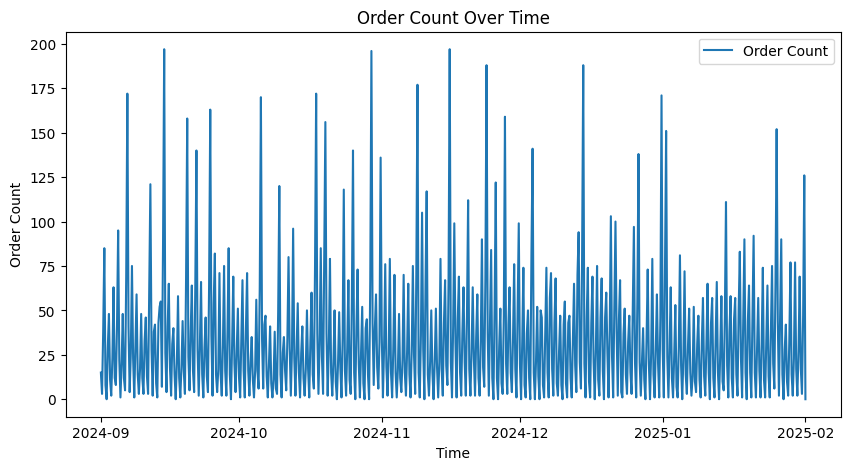

ADF Statistic: -6.101878182372185
p-value: 9.791112896941911e-08
Critical Values:
   1%: -3.4414256033746606
   5%: -2.8664262627821473
   10%: -2.569372254520843

✅ Chuỗi thời gian có tính dừng (p-value < 0.05)


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Kiểm tra nếu 'Order Hour Range' chưa phải chỉ mục thì đặt lại
if not isinstance(processed_df.index, pd.DatetimeIndex):
    processed_df.set_index("Order Hour Range", inplace=True)

# Vẽ đồ thị chuỗi thời gian để quan sát trực quan
plt.figure(figsize=(10, 5))
plt.plot(processed_df["Order Count"], label="Order Count")
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Order Count Over Time")
plt.legend()
plt.show()

# Kiểm định Augmented Dickey-Fuller (ADF)
def test_stationarity(series):
    result = adfuller(series.dropna())  # Loại bỏ NaN nếu có
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    
    if result[1] < 0.05:
        print("\n✅ Chuỗi thời gian có tính dừng (p-value < 0.05)")
    else:
        print("\n❌ Chuỗi thời gian không có tính dừng (p-value >= 0.05), cần lấy sai phân.")

# Kiểm tra tính dừng của cột Order Count
test_stationarity(processed_df["Order Count"])


GIẢI THÍCH TỪNG CHỈ SỐ TRONG KẾT QUẢ
ADF Statistic = -8.2322
Đây là giá trị thống kê của kiểm định Dickey-Fuller.
-> Giá trị này càng nhỏ (âm càng lớn) thì chuỗi thời gian càng có tính dừng.

p-value = 6.02e-13 (~0.0000000000006)
Đây là xác suất để giả thuyết H₀ (chuỗi không dừng) đúng.
Vì p-value < 0.05, bác bỏ giả thuyết H₀.
->chuỗi thời gian có tính dừng.

Critical Values (Ngưỡng kiểm định)
1% mức ý nghĩa (-3.4418)
5% mức ý nghĩa (-2.8666)
10% mức ý nghĩa (-2.5694)
→ Nếu ADF Statistic nhỏ hơn một trong các giá trị này, ta bác bỏ giả thuyết H₀.

🔍 Theo kết quả, ADF Statistic (-8.2322) nhỏ hơn tất cả các mức (-3.4418, -2.8666, -2.5694), chứng tỏ chuỗi có tính dừng rất mạnh.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import kpss

# Kiểm tra nếu 'Order Hour Range' chưa phải chỉ mục thì đặt lại
if not isinstance(processed_df.index, pd.DatetimeIndex):
    processed_df.set_index("Order Hour Range", inplace=True)


# Kiểm định KPSS
def test_kpss(series):
    result = kpss(series.dropna(), regression="c")  # "c" kiểm tra tính dừng có hằng số; dùng "ct" nếu muốn kiểm tra có xu hướng
    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[3].items():
        print(f"   {key}: {value}")
    
    if result[1] < 0.05:
        print("\n❌ Chuỗi thời gian không có tính dừng (p-value < 0.05), cần lấy sai phân.")
    else:
        print("\n✅ Chuỗi thời gian có tính dừng (p-value >= 0.05)")

# Kiểm tra tính dừng của cột Order Count
test_kpss(processed_df["Order Count"])

KPSS Statistic: 0.0746521619425213
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✅ Chuỗi thời gian có tính dừng (p-value >= 0.05)


C:\Users\minhh\AppData\Local\Temp\ipykernel_30236\295042336.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c")  # "c" kiểm tra tính dừng có hằng số; dùng "ct" nếu muốn kiểm tra có xu hướng


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=0.42 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1111.982, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1078.457, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1073.369, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1072.391, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1074.381, Time=0.07 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=inf, Time=0.30 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1070.930, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=1070.040, Time=0.08 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.26 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=1055.228, Time=0.13 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=1050.020, Time=0.16 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=inf, Time=0.58 sec
 ARIMA(1,0,5)(0,0,0)[0]             : AIC=inf, Time=0.75 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=1049.084, Time=0

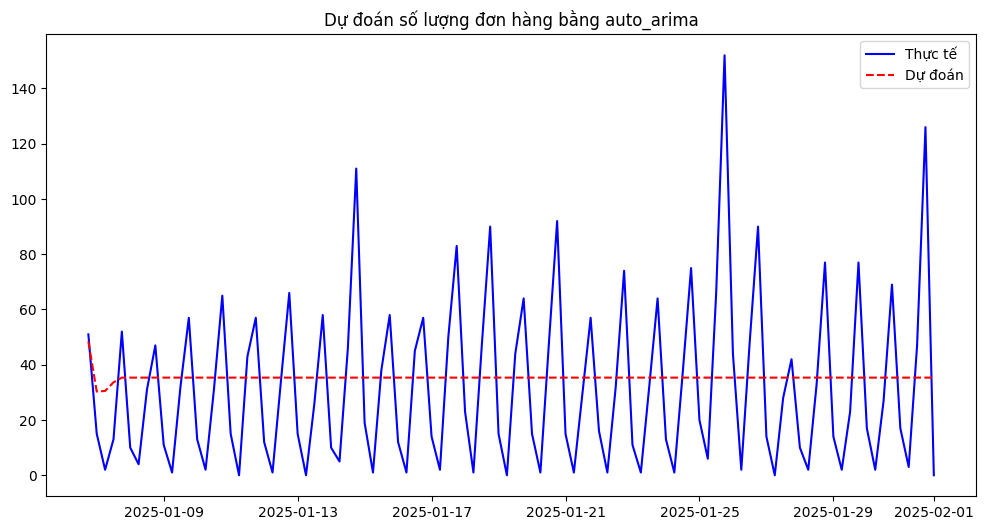

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima  # Thư viện auto_arima
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 Kiểm tra processed_df trước khi copy
if 'processed_df' not in locals():
    raise ValueError("processed_df chưa được định nghĩa!")

df = processed_df.copy()

# Chuyển 'Order Hour Range' thành datetime và thiết lập làm index
# df['Order Hour Range'] = pd.to_datetime(df['Order Hour Range'])
# df.set_index('Order Hour Range', inplace=True)

# Xác định tần suất (frequency) cho DateTimeIndex
# Phương pháp 1: Tự động xác định tần suất
#df = df.asfreq(pd.infer_freq(df.index))

# Hoặc nếu bạn biết chắc tần suất của dữ liệu (ví dụ: 'H' cho mỗi giờ, 'D' cho mỗi ngày)
df = df.asfreq('6h')  # Thay 'H' bằng tần suất phù hợp

# Kiểm tra cột dữ liệu có tồn tại không
if 'Order Count' not in df.columns:
    raise KeyError("Cột 'Order Count' không tồn tại trong DataFrame!")

# Sắp xếp theo thời gian (theo index, vì 'Order Hour Range' đã là index)
df.sort_index(inplace=True)

# 🚀 10-Fold Cross Validation với TimeSeriesSplit
n_splits = 5  # 🔄 Giảm số lượng split nếu dữ liệu ít
tscv = TimeSeriesSplit(n_splits=n_splits)

mse_scores, mae_scores, r2_scores, r2_adj_scores = [], [], [], []

# 📌 Tham số ARIMA (tự động tìm tham số với auto_arima)
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train, test = df.iloc[train_idx], df.iloc[test_idx]

    if len(train) == 0 or len(test) == 0:
        print(f"⚠ Bỏ qua Fold {i+1} vì train/test rỗng!")
        continue

    # Huấn luyện mô hình với auto_arima
    try:
        # Tìm tham số tối ưu với auto_arima
        model = auto_arima(train['Order Count'], seasonal=False, stepwise=True, trace=True)
        model_fit = model.fit(train['Order Count'])
        predictions = model.predict(n_periods=len(test))

        # Tính toán độ lỗi
        mse = mean_squared_error(test['Order Count'], predictions)
        mae = mean_absolute_error(test['Order Count'], predictions)
        r2 = r2_score(test['Order Count'], predictions)

        # Tính toán R² điều chỉnh
        n = len(test)  # Số lượng quan sát
        k = model.order[0] + model.order[1] + model.order[2]  # Số tham số trong mô hình ARIMA (p + d + q)
        r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1) if n - k - 1 > 0 else np.nan  # Tránh chia cho 0

        # Lưu kết quả
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        r2_adj_scores.append(r2_adj)

        print(f"Fold {i+1} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}, R² adj: {r2_adj:.4f}")
    except Exception as e:
        print(f"⚠ Lỗi trong Fold {i+1}: {e}")
        continue

# 📊 Kết quả trung bình sau các Fold hợp lệ
if mse_scores:
    print("\n📢 Kết quả trung bình:")
    print(f"🔹 MSE: {np.mean(mse_scores):.4f}")
    print(f"🔹 MAE: {np.mean(mae_scores):.4f}")
    print(f"🔹 R²: {np.mean(r2_scores):.4f}")
    print(f"🔹 R² adj: {np.mean(r2_adj_scores):.4f}")
else:
    print("⚠ Không có Fold nào chạy thành công!")

# 📈 Vẽ đồ thị dự đoán so với thực tế (Chỉ vẽ nếu có dữ liệu)
if len(test) > 0:
    plt.figure(figsize=(12,6))
    plt.plot(test.index, test['Order Count'], label="Thực tế", color="blue")  # Sử dụng test.index (thời gian) làm trục x
    plt.plot(test.index, predictions, label="Dự đoán", linestyle="dashed", color="red")  # Sử dụng test.index (thời gian) làm trục x
    plt.legend()
    plt.title("Dự đoán số lượng đơn hàng bằng auto_arima")
    plt.show()
else:
    print("⚠ Không có dữ liệu để vẽ biểu đồ!")


In [67]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Order Count'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("⚠ Chuỗi không ổn định, cần khác biệt (d=1)")
else:
    print("✅ Chuỗi ổn định, không cần khác biệt (d=0)")


ADF Statistic: -6.101878182372185
p-value: 9.791112896941911e-08
✅ Chuỗi ổn định, không cần khác biệt (d=0)


<Figure size 800x400 with 0 Axes>

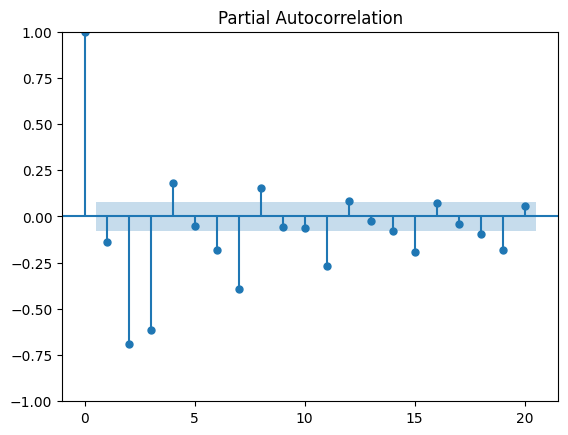

In [79]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_pacf(processed_df['Order Count'].diff().dropna(), lags=20)
plt.show()


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima  # Thư viện auto_arima
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 Kiểm tra processed_df trước khi copy
if 'processed_df' not in locals():
    raise ValueError("processed_df chưa được định nghĩa!")

df = processed_df.copy()

# Chuyển 'Order Hour Range' thành datetime và thiết lập làm index
# df['Order Hour Range'] = pd.to_datetime(df['Order Hour Range'])
# df.set_index('Order Hour Range', inplace=True)

# Xác định tần suất (frequency) cho DateTimeIndex
# Phương pháp 1: Tự động xác định tần suất
df = df.asfreq(pd.infer_freq(df.index))

# Hoặc nếu bạn biết chắc tần suất của dữ liệu (ví dụ: 'H' cho mỗi giờ, 'D' cho mỗi ngày)
# df = df.asfreq('H')  # Thay 'H' bằng tần suất phù hợp

# Kiểm tra cột dữ liệu có tồn tại không
if 'Order Count' not in df.columns:
    raise KeyError("Cột 'Order Count' không tồn tại trong DataFrame!")

# Sắp xếp theo thời gian (theo index, vì 'Order Hour Range' đã là index)
df.sort_index(inplace=True)

# 🚀 10-Fold Cross Validation với TimeSeriesSplit
n_splits = 5  # 🔄 Giảm số lượng split nếu dữ liệu ít
tscv = TimeSeriesSplit(n_splits=n_splits)

mse_scores, mae_scores, r2_scores, r2_adj_scores = [], [], [], []

# 📌 Tham số ARIMA (tự động tìm tham số với auto_arima)
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train, test = df.iloc[train_idx], df.iloc[test_idx]

    if len(train) == 0 or len(test) == 0:
        print(f"⚠ Bỏ qua Fold {i+1} vì train/test rỗng!")
        continue

    # Huấn luyện mô hình với auto_arima
    try:
        # Tìm tham số tối ưu với auto_arima
        model = auto_arima(train['Order Count'], seasonal=False, stepwise=True, trace=True)
        model_fit = model.fit(train['Order Count'])
        predictions = model.predict(n_periods=len(test))

        # Tính toán độ lỗi
        mse = mean_squared_error(test['Order Count'], predictions)
        mae = mean_absolute_error(test['Order Count'], predictions)
        r2 = r2_score(test['Order Count'], predictions)

        # Tính toán R² điều chỉnh
        n = len(test)  # Số lượng quan sát
        k = model.order[0] + model.order[1] + model.order[2]  # Số tham số trong mô hình ARIMA (p + d + q)
        r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1) if n - k - 1 > 0 else np.nan  # Tránh chia cho 0

        # Lưu kết quả
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        r2_adj_scores.append(r2_adj)

        print(f"Fold {i+1} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}, R² adj: {r2_adj:.4f}")
    except Exception as e:
        print(f"⚠ Lỗi trong Fold {i+1}: {e}")
        continue

# 📊 Kết quả trung bình sau các Fold hợp lệ
if mse_scores:
    print("\n📢 Kết quả trung bình:")
    print(f"🔹 MSE: {np.mean(mse_scores):.4f}")
    print(f"🔹 MAE: {np.mean(mae_scores):.4f}")
    print(f"🔹 R²: {np.mean(r2_scores):.4f}")
    print(f"🔹 R² adj: {np.mean(r2_adj_scores):.4f}")
else:
    print("⚠ Không có Fold nào chạy thành công!")

# 📈 Vẽ đồ thị dự đoán so với thực tế (Chỉ vẽ nếu có dữ liệu)
if len(test) > 0:
    plt.figure(figsize=(12,6))
    plt.plot(test.index, test['Order Count'], label="Thực tế", color="blue")  # Sử dụng test.index (thời gian) làm trục x
    plt.plot(test.index, predictions, label="Dự đoán", linestyle="dashed", color="red")  # Sử dụng test.index (thời gian) làm trục x
    plt.legend()
    plt.title("Dự đoán số lượng đơn hàng bằng auto_arima")
    plt.show()
else:
    print("⚠ Không có dữ liệu để vẽ biểu đồ!")


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [84]:

print(processed_df.index)

print(df.index)

print(df.isna().sum())  # Kiểm tra số lượng NaN trong từng cột
nan_rows = df[df['Order Count'].isna()]
print(nan_rows)

mean_order_count = df['Order Count'].mean()

print(f"Trung bình số lượng đơn hàng: {mean_order_count:.2f}")



DatetimeIndex(['2024-09-01 00:00:00', '2024-09-01 06:00:00',
               '2024-09-01 12:00:00', '2024-09-01 18:00:00',
               '2024-09-02 00:00:00', '2024-09-02 06:00:00',
               '2024-09-02 12:00:00', '2024-09-02 18:00:00',
               '2024-09-03 00:00:00', '2024-09-03 06:00:00',
               ...
               '2025-01-29 18:00:00', '2025-01-30 00:00:00',
               '2025-01-30 06:00:00', '2025-01-30 12:00:00',
               '2025-01-30 18:00:00', '2025-01-31 00:00:00',
               '2025-01-31 06:00:00', '2025-01-31 12:00:00',
               '2025-01-31 18:00:00', '2025-02-01 00:00:00'],
              dtype='datetime64[ns]', name='Order Hour Range', length=613, freq=None)
DatetimeIndex(['2024-09-01 00:00:00', '2024-09-01 06:00:00',
               '2024-09-01 12:00:00', '2024-09-01 18:00:00',
               '2024-09-02 00:00:00', '2024-09-02 06:00:00',
               '2024-09-02 12:00:00', '2024-09-02 18:00:00',
               '2024-09-03 00:00:00', '2

C:\Users\minhh\AppData\Local\Temp\ipykernel_30236\1051662724.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_hours = pd.date_range(start=df['Order Placed At'].min().floor('6h'),


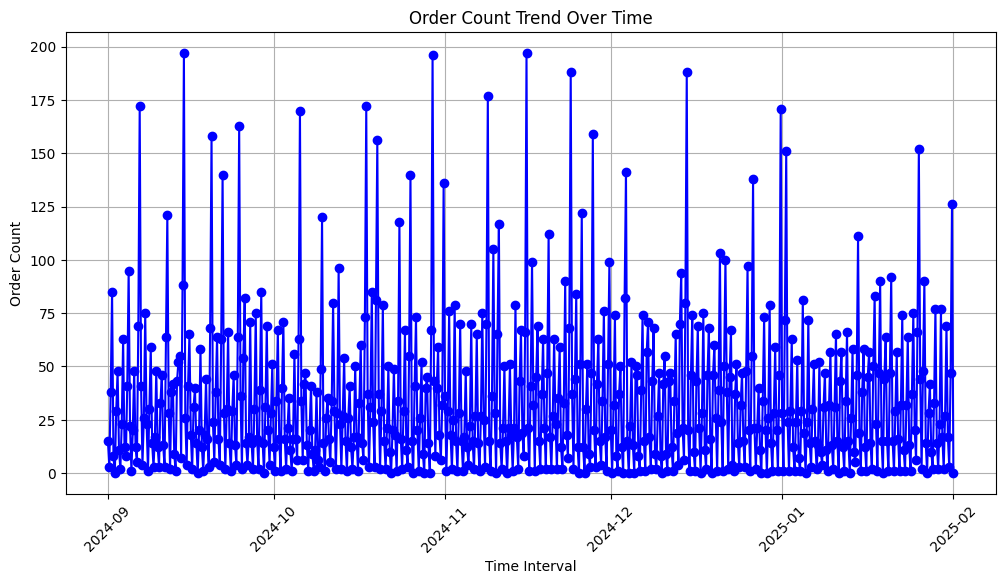

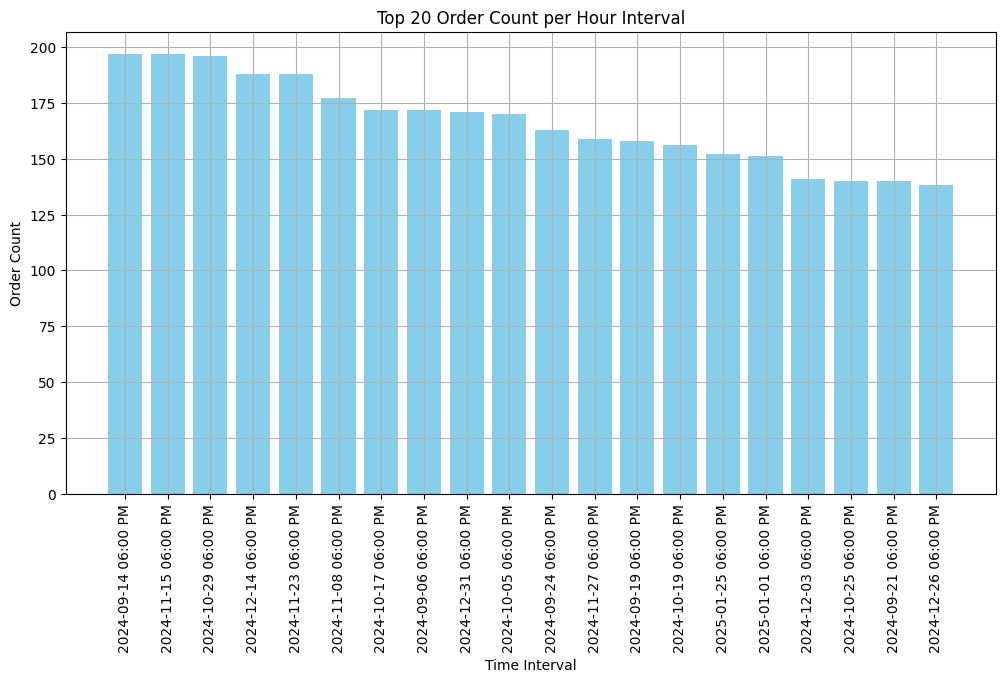

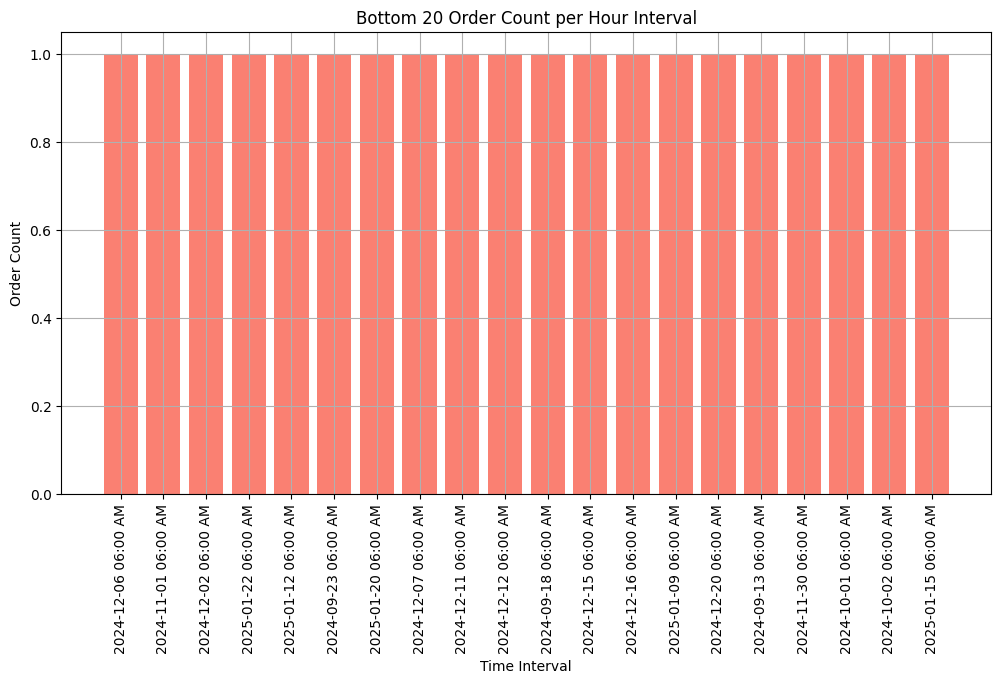


Bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):
   Order Hour Range  Order Count
2025-02-01 00:00:00            0
2024-10-22 06:00:00            0
2024-11-12 06:00:00            0
2025-01-13 06:00:00            0
2025-01-11 06:00:00            0
2024-11-25 06:00:00            0
2024-11-26 06:00:00            0
2025-01-05 06:00:00            0
2024-12-29 06:00:00            0
2025-01-19 06:00:00            0
2024-12-01 06:00:00            0
2024-12-03 06:00:00            0
2024-12-04 06:00:00            0
2024-12-05 06:00:00            0
2024-09-29 06:00:00            0
2024-12-19 06:00:00            0
2024-10-29 06:00:00            0
2024-12-17 06:00:00            0
2024-12-10 06:00:00            0
2024-12-28 06:00:00            0
2024-11-10 06:00:00            0
2024-09-17 06:00:00            0
2024-10-28 06:00:00            0
2025-01-27 06:00:00            0
2024-09-02 06:00:00            0
2024-10-26 06:00:00            0
2024-11-03 06:00:00            1

,Order Hour Range,Order Count
0,2024-09-01 00:00:00,15
1,2024-09-01 06:00:00,3
2,2024-09-01 12:00:00,38
3,2024-09-01 18:00:00,85
4,2024-09-02 00:00:00,8
...,...,...
95,2024-09-24 18:00:00,163
96,2024-09-25 00:00:00,36
97,2024-09-25 06:00:00,2
98,2024-09-25 12:00:00,54


In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tệp CSV và thêm cột đếm số lượng đơn hàng theo khung giờ
def process_data(file_path):
    df = pd.read_csv(file_path)
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    
    # Tạo cột 'Order Hour Range' để nhóm theo từng khung giờ (cách nhau 6 tiếng)
    df['Order Hour Range'] = df['Order Placed At'].dt.floor('6h')  # Cách nhau 6 tiếng
    
    # Đếm số lượng đơn hàng theo từng khung giờ
    order_counts = df.groupby('Order Hour Range').size().reset_index(name='Order Count')
    
    # Tạo một dãy thời gian đầy đủ từ thời điểm sớm nhất đến muộn nhất với khung giờ 6 tiếng
    all_hours = pd.date_range(start=df['Order Placed At'].min().floor('6h'),
                              end=df['Order Placed At'].max().ceil('6h'),
                              freq='6H')
    
    # Tạo DataFrame với tất cả các khung giờ đầy đủ
    all_hours_df = pd.DataFrame(all_hours, columns=['Order Hour Range'])
    
    # Merge với bảng order_counts để điền các khung giờ không có đơn hàng (fill NaN với 0)
    full_order_counts = pd.merge(all_hours_df, order_counts, on='Order Hour Range', how='left').fillna(0)
    full_order_counts['Order Count'] = full_order_counts['Order Count'].astype(int)
    
    # Sắp xếp theo khung giờ
    full_order_counts = full_order_counts.sort_values(by='Order Hour Range')

    # Vẽ biểu đồ đường thể hiện số đơn hàng theo từng khung giờ theo thời gian
    plt.figure(figsize=(12, 6))
    plt.plot(full_order_counts['Order Hour Range'], full_order_counts['Order Count'], marker='o', linestyle='-', color='b')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count Trend Over Time')
    plt.xticks(rotation=45)  # Xoay trục hoành để hiển thị đầy đủ ngày và giờ
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng theo thời gian - Top 20 orders
    plt.figure(figsize=(12, 6))
    top_20_orders = order_counts.sort_values(by='Order Count', ascending=False).head(20)
    plt.bar(top_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), top_20_orders['Order Count'], color='skyblue')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Top 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng ít nhất theo thời gian - Bottom 20 orders
    plt.figure(figsize=(12, 6))
    bottom_20_orders = order_counts.sort_values(by='Order Count', ascending=True).head(20)
    plt.bar(bottom_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), bottom_20_orders['Order Count'], color='salmon')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Bottom 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Xuất bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (hiển thị 100 dòng đầu tiên)
    sorted_order_counts = full_order_counts.sort_values(by='Order Count', ascending=True).head(100)
    print("\nBảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):")
    print(sorted_order_counts.to_string(index=False))
    
    return full_order_counts

# Đường dẫn đến tệp dữ liệu đầu vào
file_path = "cleaned_order_history.csv"
processed_df = process_data(file_path)

processed_df.head(100)
